## Derivation

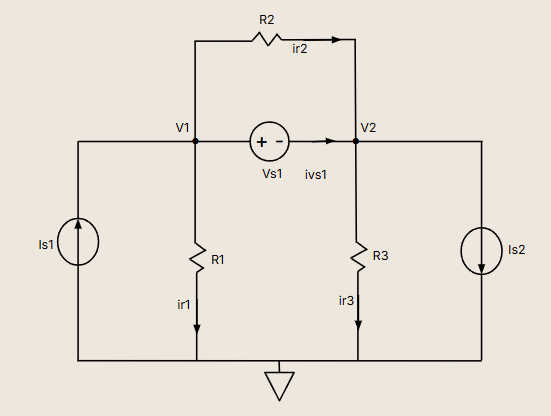

Deriving the general matrix form for circuits containing **indpendent voltage sources** along with **indpendent current sources** and resistors:

1. **Node-1**:

$$
-I_{s1} + i_{r1} + i_{r2} + i_{V_{s1}} = 0 \\[1em]
\Rightarrow \frac{V_1}{R_1} + \frac{(V_1 - V_2)}{R_2} + i_{V_{s1}} = I_{s1} \\[1em]
\Rightarrow (\frac{1}{R_1} + \frac{1}{R_2})V_1 -\frac{1}{R_1}V_2 + 1\cdot i_{V_{s1}}  = I_{s1}  
$$
<br><br>

2. **Node-2:**

$$
-i_{r2} - i_{V_{s1}} + i_{r3} + I_{s2} = 0 \\[1em]
\Rightarrow -\frac{(V_1 - V_2)}{R_2} - i_{V_{s1}} + \frac{V_2}{R_3} = -I_{s2}  \\[1em]
\Rightarrow -\frac{1}{R_2}V_1 + (\frac{1}{R_2} + \frac{1}{R_3})V_2 -1\cdot i_{V_{s1}} = -I_{s2}
$$

<br><br>

3. **Constraint Equation:**

$$1\cdot V_1 -1 \cdot V_2 + 0\cdot i_{V_{s1}} = V_{s1}$$

<br><br>

4. **Matrix Form:**
$$
\begin{bmatrix}
(\frac{1}{R_1} + \frac{1}{R_2}) & -\frac{1}{R_2} & 1 \\
-\frac{1}{R_2} & (\frac{1}{R_2} + \frac{1}{R_3}) & -1 \\
1 & -1 & 0
\end{bmatrix}
\cdot
\begin{bmatrix}
V_1 \\ V_2 \\ i_{V_{s1}}
\end{bmatrix}
=
\begin{bmatrix}
I_{s1} \\ -I_{s2} \\ V_{s1}
\end{bmatrix}
$$

## MNA ALGORITHM

Matrix Form:

$$
\begin{bmatrix}
G & B \\ C & D
\end{bmatrix} \cdot
\begin{bmatrix}
v \\ j
\end{bmatrix} =
\begin{bmatrix}
i \\ e
\end{bmatrix}
$$

Basic Conventions:
1. Number of Nodes -> `n`
2. Number of Voltage Sources -> `m`

**QUICK SUMMARY**

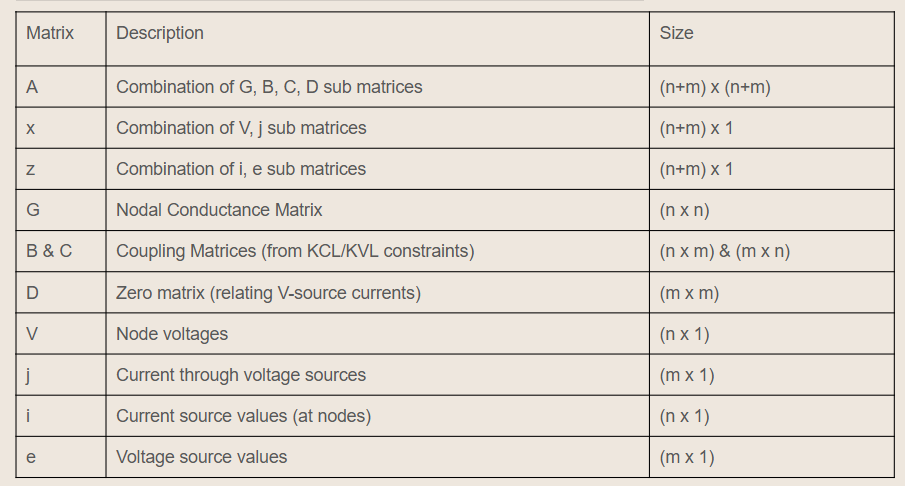

### Example

In [ ]:
from typing import Dict, List, Any
import numpy as np

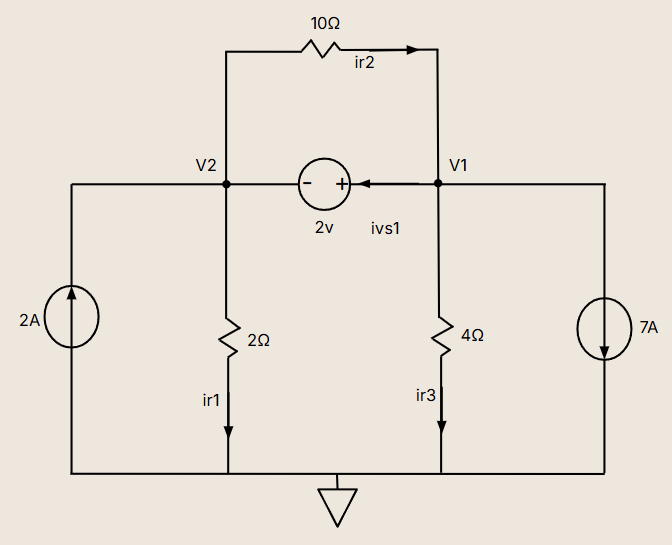

**CONVENTIONS** (in priority):
1. Positive terminal of votltage source is connected to node 1 and negative terminal to node 2.

2. Currents flow out of node 1 to node 2.

In [ ]:
components = [
    {'type': 'Is', 'n1': 0, 'n2': 2, 'value': 2},
    {'type': 'R', 'n1': 2, 'n2': 0, 'value': 2},
    {'type': 'R', 'n1': 2, 'n2': 1, 'value': 10},
    {'type': 'Vs', 'n1': 1, 'n2': 2, 'value': 2},
    {'type': 'R', 'n1': 1, 'n2': 0, 'value': 4},
    {'type': 'Is', 'n1': 1, 'n2': 0, 'value': 7},
]


Calculate number of nodes, number of voltage sources and seperate components for cleaner workflow.

In [ ]:
max_node = 0
resistor_components = []
voltage_source_components = []
current_source_components = []

for component in components:
    max_node = max(max_node, component["n1"], component["n2"])

    if component["type"] == "R":
        resistor_components.append(component)
    elif component["type"] == "Vs":
        voltage_source_components.append(component)
    elif component["type"] == "Is":
        current_source_components.append(component)

num_nodes = max_node
num_voltage_sources = len(voltage_source_components)
T = num_nodes + num_voltage_sources

print(
    f'Number of nodes: {num_nodes}',
    f'\nNumber of voltage sources: {num_voltage_sources}',
    f'\nTotal number of equations: {T}',
    )

Number of nodes: 2 
Number of voltage sources: 1 
Total number of equations: 3


In [ ]:
A = np.zeros((T, T))
z = np.zeros((T, 1))

### G MATRIX

Rules:
- **Diagonal elements**: Sum of the conductance (one over the resistance) of each element connected to the corresponding node.
- **Off diagonal elements**: Negative sum of conductance of the element connected to the pair of corresponding node

In [ ]:
for component in resistor_components:
    n1 = component["n1"]
    n2 = component["n2"]
    g = 1 / component["value"]

    if n1 > 0: A[n1-1, n1-1] += g
    if n2 > 0: A[n2-1, n2-1] += g

    if n1 > 0 and n2 > 0:
        A[n1-1, n2-1] -= g
        A[n2-1, n1-1] -= g

print(f'G MATRIX:\n{A[:num_nodes, :num_nodes]}')

G MATRIX:
[[ 0.35 -0.1 ]
 [-0.1   0.6 ]]


### B & C MATRICES

Rules for constructing B Matrix:
1.  If the positive terminal of the ith voltage source is connected to node k, then **add 1** to $B(k, i)$ element.
2. If the negative terminal of the ith voltage source is connected to node k, then **subtract 1** to $B(k, i)$ element.

$C$ Matrix is essentially transpose of $B$ in this case. (Rules are correspond to $C(k,i)$ elements)
$$C = B^T$$

In [ ]:
for vs_idx, component in enumerate(voltage_source_components):
    n1 = component["n1"]
    n2 = component["n2"]
    v = component["value"]

    if n1 > 0:
        A[n1-1, vs_idx + num_nodes] += 1
        A[vs_idx + num_nodes, n1-1] += 1

    if n2 > 0:
        A[n2-1, vs_idx + num_nodes] -= 1
        A[vs_idx + num_nodes, n2-1] -= 1

print(
    f'\nA:\n{A}'
    f'\n\nB:\n{A[:num_nodes:, num_nodes:]}'
    f'\n\nC:\n{A[num_nodes:, :num_nodes]}'
    )


A:
[[ 0.35 -0.1   1.  ]
 [-0.1   0.6  -1.  ]
 [ 1.   -1.    0.  ]]

B:
[[ 1.]
 [-1.]]

C:
[[ 1. -1.]]


### i Matrix

For $i$ matrix:
 - The value of each element of i is determined by the **sum of current sources entering** into the corresponding node.
 - If there are no current sources connected to the node, the value is **zero**.

In [ ]:
for component in current_source_components:
    n1 = component["n1"]
    n2 = component["n2"]
    i = component["value"]

    if n1 > 0: z[n1-1] -= i
    if n2 > 0: z[n2-1] += i

print(f'i MATRIX:\n{z[:num_nodes]}')

i MATRIX:
[[-7.]
 [ 2.]]


### e Matrix

For $e$ matrix:
Each element of the matrix equal in value to the corresponding independent voltage source.

In [ ]:
for vs_idx, component in enumerate(voltage_source_components):
    n1 = component["n1"]
    n2 = component["n2"]
    v = component["value"]

    z[num_nodes + vs_idx] = v

print(f'e MATRIX:\n{z[num_nodes:]}')

e MATRIX:
[[2.]]


### x Matrix

The x matrix holds our unknown node voltages and current through independent voltage sources.
$$x = A^{-1} z$$

In [ ]:
x = np.linalg.solve(A, z)
print(
    f'Node Voltages:\n{x[:num_nodes]}',
    f'\n\nCurrents through voltage sources:\n{x[num_nodes:]}'
)

Node Voltages:
[[-5.33333333]
 [-7.33333333]] 

Currents through voltage sources:
[[-5.86666667]]


### Branch Currents

We can get current through resistors based on node voltages.

In [ ]:
resistor_currents = np.zeros((len(resistor_components), ))
for res_idx, component in enumerate(resistor_components):
    n1 = component["n1"]
    n2 = component["n2"]
    g = 1 / component["value"]
    vn1 = x[n1-1].item() if n1 > 0 else 0
    vn2 = x[n2-1].item() if n2 > 0 else 0
    resistor_currents[res_idx] = (vn1 - vn2) * g

print(f'Resistor Currents:\n{resistor_currents}')

Resistor Currents:
[-3.66666667 -0.2        -1.33333333]


### Mannual Verification

Using the supernode technique and KCL at nodes 1 and 2 we get:

$2 = i_{r1} + i_{r3} + 7$

Current in Resistor-1 :

$i_{r1}  = \frac{(V_2 - 0)}{2}$

Current in resistor 2:

$i_{r2} = \frac{(V_1 - V_2)}{10}$

Current in resistor-3:

$i_{r3} = \frac{(V_1-0)}{4}$

Constraint equation:

$V_1 - V_2 = 2\\
\Rightarrow V_1 = 2 + V_2
$

Substitutting $i_{r1}$ and $i_{r3} in first equation:

$
\Rightarrow 2 = \frac{V_2}{2} + \frac{V_1}{4} + 7 \\
\Rightarrow 2V_2 + V_1 = -20
$

Substitutting $V_1$ expression obtained from constraint equation into above equation:

$
\Rightarrow 3V_2 + 2 = -20 \\
\Rightarrow V_2 = -7.3333 V \\
\Rightarrow V_1 = -5.3333 V
$

Calculating branch resistor currents:

$
\Rightarrow i_{r1} = -3.6667 A \\
\Rightarrow i_{r2} = -0.2 A \\
\Rightarrow i_{r3} = -1.333 A
$

## Complete Solver Class

A Generalized implementation collecting all we have discussed into a class.

In [ ]:
class MNASolver:
    def __init__(self, components: List[Dict[str, Any]]):
        self.components = components

        self.parse_components()
        self.intialize_matrices()

    def parse_components(self):
        max_node = 0
        self.resistor_components = []
        self.voltage_source_components = []
        self.current_source_components = []

        for component in self.components:
            max_node = max(max_node, component["n1"], component["n2"])

            if component["type"] == "R":
                self.resistor_components.append(component)
            elif component["type"] == "Vs":
                self.voltage_source_components.append(component)
            elif component["type"] == "Is":
                self.current_source_components.append(component)

        self.num_nodes = max_node
        self.num_voltage_sources = len(self.voltage_source_components)
        self.T = self.num_nodes + self.num_voltage_sources

    def intialize_matrices(self):
        self.A = np.zeros((self.T, self.T))
        self.z = np.zeros((self.T, 1))

    def fill_G(self):
        for component in self.resistor_components:
            n1 = component["n1"]
            n2 = component["n2"]
            g = 1 / component["value"]

            if n1 > 0: self.A[n1-1, n1-1] += g
            if n2 > 0: self.A[n2-1, n2-1] += g

            if n1 > 0 and n2 > 0:
                self.A[n1-1, n2-1] -= g
                self.A[n2-1, n1-1] -= g

    def fill_B_C_e(self):
        for vs_idx, component in enumerate(self.voltage_source_components):
            n1 = component["n1"]
            n2 = component["n2"]
            v = component["value"]

            # Fill B and C matrices
            if n1 > 0:
                self.A[n1-1, vs_idx + num_nodes] += 1
                self.A[vs_idx + num_nodes, n1-1] += 1

            if n2 > 0:
                self.A[n2-1, vs_idx + num_nodes] -= 1
                self.A[vs_idx + num_nodes, n2-1] -= 1

            # Fill e matrix
            self.z[num_nodes + vs_idx] = v

    def fill_i(self):
        for component in self.current_source_components:
            n1 = component["n1"]
            n2 = component["n2"]
            i = component["value"]

            if n1 > 0: self.z[n1-1] -= i
            if n2 > 0: self.z[n2-1] += i

    def get_resistor_currents(self):
        resistor_currents = np.zeros((len(self.resistor_components), ))
        for res_idx, component in enumerate(self.resistor_components):
            n1 = component["n1"]
            n2 = component["n2"]
            g = 1 / component["value"]
            vn1 = x[n1-1].item() if n1 > 0 else 0
            vn2 = x[n2-1].item() if n2 > 0 else 0
            resistor_currents[res_idx] = (vn1 - vn2) * g
        return resistor_currents


    def solve(self):
        self.fill_G()
        self.fill_B_C_e()
        self.fill_i()
        self.x = np.linalg.solve(self.A, self.z)
        resistor_currents = self.get_resistor_currents()

        result_dict = {}
        for idx in range(self.num_nodes):
            result_dict[f'V ({idx+1})'] = self.x[idx].item()
        for idx, component in enumerate(self.voltage_source_components):
            result_dict[f'js ({idx+1})'] = self.x[idx + num_nodes].item()
        for idx, component in enumerate(self.resistor_components):
            result_dict[f'Ir ({component["n1"]}, {component["n2"]})'] = resistor_currents[idx].item()

        return result_dict

In [ ]:
components = [
    {'type': 'Is', 'n1': 0, 'n2': 2, 'value': 2},
    {'type': 'R', 'n1': 2, 'n2': 0, 'value': 2},
    {'type': 'R', 'n1': 2, 'n2': 1, 'value': 10},
    {'type': 'Vs', 'n1': 1, 'n2': 2, 'value': 2},
    {'type': 'R', 'n1': 1, 'n2': 0, 'value': 4},
    {'type': 'Is', 'n1': 1, 'n2': 0, 'value': 7},
]

In [ ]:
solver = MNASolver(components)
results = solver.solve()

print('Modified Nodal Analysis Summary:\n')
for k, v in results.items():
    print(f'{k:<20} {v:.4f}')

Modified Nodal Analysis Summary:

V (1)                -5.3333
V (2)                -7.3333
js (1)               -5.8667
Ir (2, 0)            -3.6667
Ir (2, 1)            -0.2000
Ir (1, 0)            -1.3333
